First we will import necessary datasets and libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from ml_from_scratch.unsupervised.K_means_clustering import KMeans

Next we will load our data

In [3]:
data = load_iris()
X = data.data
y_true = data.target

Note that we are only storing y_true to test for accuracy of the algorithm. As K Means Clustering is unsupervised, it will never see the labels. Now we will apply our model to the data to see what it gets us

In [4]:
model = KMeans(k=3, max_iters=100, random_state=42)
model.fit(X)
clusters = model.labels 

Now we will graph our clusters and our expected values to see how accurate the algorithm predicted the species

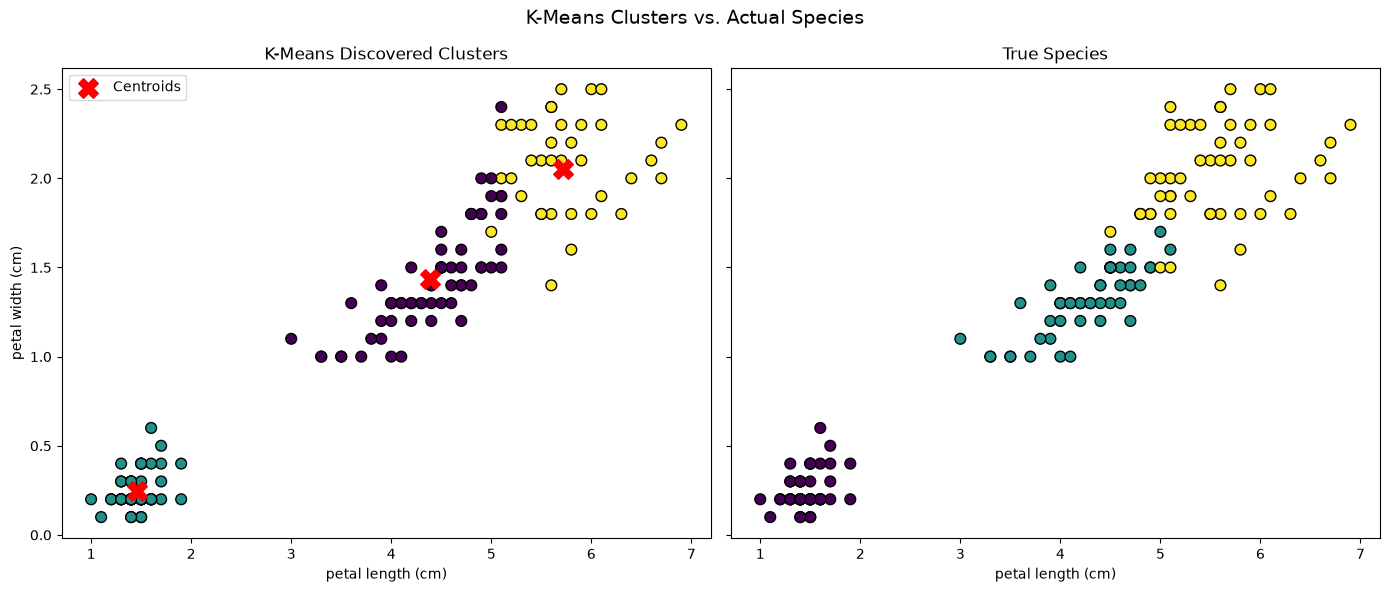

In [5]:
f1, f2 = 2, 3 

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

axes[0].scatter(X[:, f1], X[:, f2], c=clusters, cmap='viridis', edgecolor='k', s=60)
axes[0].scatter(model.centroids[:, f1], model.centroids[:, f2],
                c='red', marker='X', s=200, label='Centroids')
axes[0].set_title('K-Means Discovered Clusters')
axes[0].set_xlabel(data.feature_names[f1])
axes[0].set_ylabel(data.feature_names[f2])
axes[0].legend()

axes[1].scatter(X[:, f1], X[:, f2], c=y_true, cmap='viridis', edgecolor='k', s=60)
axes[1].set_title('True Species')
axes[1].set_xlabel(data.feature_names[f1])

plt.suptitle('K-Means Clusters vs. Actual Species', fontsize=14)
plt.tight_layout()
plt.show()

We must test now for accuracy. Note that the K-Means algorithm labels and the iris labels will differ, so assuming that K-means is somewhat accurate, which we know for sure from the plots, we will assign each clump what it is majority made up of on the real data.

In [6]:
accuracy = sum(
    np.sum((clusters == c) & (y_true == np.bincount(y_true[clusters == c]).argmax()))
    for c in range(3)
) / len(y_true)

print(f"Clustering accuracy: {accuracy:.2%}")

Clustering accuracy: 88.67%


Now this is lower than a lot of the other models, however note that 89% is not bad at all for a model with no training at all. This model is simply finding groups within the data. Also note that it does depend on the data, this data is separable enough that the algorithm does a good job, however that is not always the case.